# Pairwise Ranking Router Training

This notebook trains a VLM router using **pairwise ranking** approach.

## Approach

Instead of predicting absolute rewards, we learn to **rank models** by comparing pairs:
- For each (sample, mode), create pairs (model_i, model_j) where model_i outperforms model_j
- Train router to assign higher scores to better models
- Loss: Margin Ranking Loss - encourage score(model_i) > score(model_j) + margin

## Benefits

- **Relative judgments**: Easier than absolute reward prediction
- **Robust to calibration**: Only ranking matters, not absolute scores
- **Proven in ranking tasks**: Used in learning-to-rank, recommendation systems

## Sections

1. Setup & Configuration
2. Load Data from SQL
3. Compute Rewards & Generate Pairs
4. Build Pairwise Dataset
5. Train Pairwise Router
6. Evaluate & Compare to Oracle
7. Visualizations

## 1. Setup & Configuration

In [6]:
# === Path Setup ===
import sys
from pathlib import Path

# Notebook paths
NOTEBOOK_DIR = Path.cwd()
ARTEMIS_DIR = NOTEBOOK_DIR.parent.parent  # artemis_final/
ROOT_DIR = ARTEMIS_DIR.parent             # Which_VLM_Router/
ROUTER_TRAIN_DIR = ARTEMIS_DIR / 'router_train'

# Add to sys.path for imports
for p in [str(ARTEMIS_DIR), str(ROOT_DIR), str(ROUTER_TRAIN_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"📁 Setup complete")

# Add artemis_final to path
# Also add router_train for local imports

import logging
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# Local imports
from config import DBConfig, RewardWeights
from db_utils import load_profiles_real_schema, load_from_sqlite, test_connection
from reward_definitions import compute_rewards_real_schema
from training.pairwise_dataset import (
    generate_pairwise_examples,
    PairwiseRouterDataset,
    collate_pairwise_batch,
)
from models.pairwise_router import PairwiseRouterModel

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


✓ Imports successful
PyTorch version: 2.9.1+cu128
CUDA available: True


In [7]:
# Configuration
LIMIT = 1000  # Set to None for full dataset, or use small number for testing
DATA_SPLIT = "train"  # Load only training data

# Pairwise generation settings
MIN_MARGIN = 0.05  # Minimum reward difference to include pair
MAX_PAIRS_PER_SAMPLE = 20  # Limit pairs per (sample, mode) to avoid explosion

# Training settings
BATCH_SIZE = 16
NUM_EPOCHS = 5
LEARNING_RATE = 2e-5
MARGIN = 1.0  # Margin for ranking loss
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Paths
DATA_DIR = Path("../data")
MODELS_DIR = Path("../models/checkpoints")
DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True, parents=True)

print("Configuration:")
print(f"  LIMIT: {LIMIT}")
print(f"  DATA_SPLIT: {DATA_SPLIT}")
print(f"  MIN_MARGIN: {MIN_MARGIN}")
print(f"  MAX_PAIRS_PER_SAMPLE: {MAX_PAIRS_PER_SAMPLE}")
print(f"  BATCH_SIZE: {BATCH_SIZE}")
print(f"  NUM_EPOCHS: {NUM_EPOCHS}")
print(f"  LEARNING_RATE: {LEARNING_RATE}")
print(f"  MARGIN: {MARGIN}")
print(f"  DEVICE: {DEVICE}")

Configuration:
  LIMIT: 1000
  DATA_SPLIT: train
  MIN_MARGIN: 0.05
  MAX_PAIRS_PER_SAMPLE: 20
  BATCH_SIZE: 16
  NUM_EPOCHS: 5
  LEARNING_RATE: 2e-05
  MARGIN: 1.0
  DEVICE: cuda


## 2. Load Data from SQL

In [8]:
# # Load database configuration
# db_config = DBConfig.from_env()

# # Test connection
# print("Testing database connection...")
# if test_connection(db_config):
#     print("✓ Database connection successful")
# else:
#     raise RuntimeError("Database connection failed. Check credentials.")

In [10]:
# Load profiling data (SQLite cache preferred)
USE_SQLITE_CACHE = True  # Set False to force PostgreSQL
SQLITE_DB_PATH = Path("../data") / "vlm_router_cache.db"
SQLITE_TABLE_NAME = "vlm_profiles"

print(f"Loading profiling data (data_split={DATA_SPLIT}, limit={LIMIT})...")

df_profiles = None
if USE_SQLITE_CACHE and SQLITE_DB_PATH.exists():
    print(f"  Source: SQLite -> {SQLITE_DB_PATH} ({SQLITE_TABLE_NAME})")
    df_profiles = load_from_sqlite(
        db_path=SQLITE_DB_PATH,
        table_name=SQLITE_TABLE_NAME,
        data_split=DATA_SPLIT,
        limit=LIMIT,
    )
else:
    if USE_SQLITE_CACHE:
        print(f"  SQLite file not found at {SQLITE_DB_PATH}, falling back to DB")
    print(f"  Source: PostgreSQL -> {db_config.host}:{db_config.port}/{db_config.name}")
    df_profiles = load_profiles_real_schema(
        db_config=db_config,
        limit=LIMIT,
        data_split=DATA_SPLIT,
    )

print(f"✓ Loaded {len(df_profiles)} profile records")
print(f"  Unique samples: {df_profiles['sample_id'].nunique()}")
print(f"  Unique models: {df_profiles['model_name'].nunique()}")
print(f"  Models: {sorted(df_profiles['model_name'].unique())}")

# Show sample
df_profiles.head()


2025-12-06 17:20:14,384 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-06 17:20:14,384 - db_utils - INFO - Loading from ../data/vlm_router_cache.db:vlm_profiles
2025-12-06 17:20:14,385 - db_utils - INFO -   Filtering by data_split: train
2025-12-06 17:20:14,385 - db_utils - INFO -   Limit: 1000
2025-12-06 17:20:14,394 - db_utils - INFO - Loaded 750 rows
2025-12-06 17:20:14,395 - db_utils - INFO -   Unique samples: 193
2025-12-06 17:20:14,395 - db_utils - INFO -   Unique models: 5
2025-12-06 17:20:14,396 - db_utils - INFO -   Data splits: {'train': 750}


Loading profiling data (data_split=train, limit=1000)...
  Source: SQLite -> ../data/vlm_router_cache.db (vlm_profiles)
✓ Loaded 750 profile records
  Unique samples: 193
  Unique models: 5
  Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']


,sample_id,source_config,source_dataset,router_task,data_split,prompt_raw,txt_prompt_length_chars,txt_prompt_length_words,img_width,img_height,img_aspect_ratio,model_name,model_prefix,latency_ms,cost_usd,confidence_score,glider_score
0,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,1.436266,gemma_3_27b,m5,5217.0,0.000061,0.883319,4.0
1,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,1.436266,qwen2_5_vl_3b,m2,2239.0,0.000087,0.882716,4.0
2,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,1.436266,qwen3_vl_8b_thinking,m4,4928.0,0.001156,0.906978,4.0
3,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,1.436266,qwen2_5_vl_7b,m3,2663.0,0.000168,0.874901,4.0
4,chart2text_0_a549e890,chart2text,cauldron,chart_captioning,train,Can you break down the data visualization and ...,66,11,800,557,1.436266,qwen2_5_vl_3b,m2,4327.0,0.000066,0.741361,0.0


## 3. Compute Rewards & Generate Pairs

In [11]:
# Compute multi-objective rewards
print("\nComputing rewards...")

reward_weights = RewardWeights()  # Use defaults
df_with_rewards = compute_rewards_real_schema(df_profiles, reward_weights)

print(f"✓ Computed rewards for {len(df_with_rewards)} records")
print("\nReward columns:")
reward_cols = [c for c in df_with_rewards.columns if c.startswith('reward_')]
print(reward_cols)

# Show reward statistics
print("\nReward statistics:")
print(df_with_rewards[reward_cols].describe())

2025-12-06 17:20:18,227 - reward_definitions - INFO - Computing rewards for all modes (using real schema with glider_score)...
2025-12-06 17:20:18,230 - reward_definitions - INFO - Using glider_score as primary accuracy (mean=0.658)
2025-12-06 17:20:18,232 - reward_definitions - INFO - Cost normalized: quantile=0.001229, mean=0.235
2025-12-06 17:20:18,233 - reward_definitions - INFO - Latency normalized: quantile=11474.85ms, mean=0.251
2025-12-06 17:20:18,234 - reward_definitions - INFO - Hallucination cleanliness H set to 1.0 (no hallucination signal available)
2025-12-06 17:20:18,235 - reward_definitions - INFO - Using confidence_score as C (mean=0.860)
2025-12-06 17:20:18,236 - reward_definitions - INFO - Reward (accuracy): mean=0.580, std=0.364
2025-12-06 17:20:18,237 - reward_definitions - INFO - Reward (cheap): mean=0.514, std=0.451
2025-12-06 17:20:18,237 - reward_definitions - INFO - Reward (fast): mean=0.507, std=0.429
2025-12-06 17:20:18,238 - reward_definitions - INFO - Rewa


Computing rewards...
✓ Computed rewards for 750 records

Reward columns:
['reward_accuracy', 'reward_cheap', 'reward_fast', 'reward_balanced']

Reward statistics:
       reward_accuracy  reward_cheap  reward_fast  reward_balanced
count       750.000000    750.000000   750.000000       750.000000
mean          0.580373      0.513658     0.506720         0.722115
std           0.363773      0.450759     0.428956         0.400175
min           0.000000     -0.700000    -0.700000        -0.235062
25%           0.640000      0.100000     0.100000         0.466058
50%           0.640000      0.731675     0.674565         0.822772
75%           1.000000      0.793560     0.794888         0.965145
max           1.000000      0.998821     0.998165         1.293901


In [12]:
# Expand to include all 4 modes
print("\nExpanding dataset to include all 4 routing modes...")

modes = ['accuracy', 'cheap', 'fast', 'balanced']
expanded_rows = []

for _, row in df_with_rewards.iterrows():
    for mode in modes:
        row_dict = row.to_dict()
        row_dict['mode_id'] = mode
        row_dict['reward'] = row[f'reward_{mode}']
        expanded_rows.append(row_dict)

df_expanded = pd.DataFrame(expanded_rows)

print(f"✓ Expanded to {len(df_expanded)} rows ({len(df_with_rewards)} → {len(df_expanded)})")
print(f"  Rows per mode: {len(df_expanded) // 4}")

df_expanded.head()


Expanding dataset to include all 4 routing modes...
✓ Expanded to 3000 rows (750 → 3000)
  Rows per mode: 750


,sample_id,source_config,source_dataset,router_task,data_split,prompt_raw,txt_prompt_length_chars,txt_prompt_length_words,img_width,img_height,...,cost_norm,lat_norm,H,C,reward_accuracy,reward_cheap,reward_fast,reward_balanced,mode_id,reward
0,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,...,0.049519,0.454646,1.0,0.883319,0.64,0.780997,0.528164,0.784900,accuracy,0.640000
1,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,...,0.049519,0.454646,1.0,0.883319,0.64,0.780997,0.528164,0.784900,cheap,0.780997
2,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,...,0.049519,0.454646,1.0,0.883319,0.64,0.780997,0.528164,0.784900,fast,0.528164
3,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,...,0.049519,0.454646,1.0,0.883319,0.64,0.780997,0.528164,0.784900,balanced,0.784900
4,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,...,0.071114,0.195122,1.0,0.882716,0.64,0.770661,0.701493,0.855769,accuracy,0.640000


In [13]:
# Generate pairwise examples for training
print(f"\nGenerating pairwise examples (metric=reward, min_margin={MIN_MARGIN})...")

df_pairs_train = generate_pairwise_examples(
    df=df_expanded,
    metric_column="reward",
    min_margin=MIN_MARGIN,
    max_pairs_per_sample=MAX_PAIRS_PER_SAMPLE,
)

print(f"\n✓ Generated {len(df_pairs_train)} pairwise examples")
print(f"  From {df_pairs_train['sample_id'].nunique()} unique samples")
print(f"  Pairs per sample: {len(df_pairs_train) / df_pairs_train['sample_id'].nunique():.1f} avg")

# Show pair statistics
print("\nPair margin statistics:")
print(df_pairs_train['margin'].describe())

df_pairs_train.head()


Generating pairwise examples (metric=reward, min_margin=0.05)...


2025-12-06 17:20:18,672 - training.pairwise_dataset - INFO - Generated 3301 pairwise examples
2025-12-06 17:20:18,673 - training.pairwise_dataset - INFO -   Unique samples: 183
2025-12-06 17:20:18,674 - training.pairwise_dataset - INFO -   Pairs per sample: 18.0 avg
2025-12-06 17:20:18,674 - training.pairwise_dataset - INFO -   Margin range: [0.050, 1.672]



✓ Generated 3301 pairwise examples
  From 183 unique samples
  Pairs per sample: 18.0 avg

Pair margin statistics:
count    3301.000000
mean        0.522168
std         0.325586
min         0.050058
25%         0.251429
50%         0.464252
75%         0.731874
max         1.671827
Name: margin, dtype: float64


,sample_id,mode_id,model_i,model_j,metric_i,metric_j,margin,prompt_raw,txt_prompt_length_chars,txt_prompt_length_words,img_width,img_height,img_aspect_ratio,source_dataset,router_task,data_split
0,ai2d_0_47e3d3a2,accuracy,gemma_3_27b,deepseek_ocr,0.64,0.00,0.64,Question: What is the correct order of develop...,231,39,541,330,1.639394,cauldron,diagram_reasoning,train
1,ai2d_0_47e3d3a2,accuracy,qwen2_5_vl_3b,deepseek_ocr,1.00,0.00,1.00,Question: What is the correct order of develop...,231,39,541,330,1.639394,cauldron,diagram_reasoning,train
2,ai2d_0_47e3d3a2,accuracy,qwen2_5_vl_3b,gemma_3_27b,1.00,0.64,0.36,Question: What is the correct order of develop...,231,39,541,330,1.639394,cauldron,diagram_reasoning,train
3,ai2d_0_47e3d3a2,accuracy,qwen2_5_vl_3b,qwen3_vl_8b_thinking,1.00,0.64,0.36,Question: What is the correct order of develop...,231,39,541,330,1.639394,cauldron,diagram_reasoning,train
4,ai2d_0_47e3d3a2,accuracy,qwen2_5_vl_7b,deepseek_ocr,1.00,0.00,1.00,Question: What is the correct order of develop...,231,39,541,330,1.639394,cauldron,diagram_reasoning,train


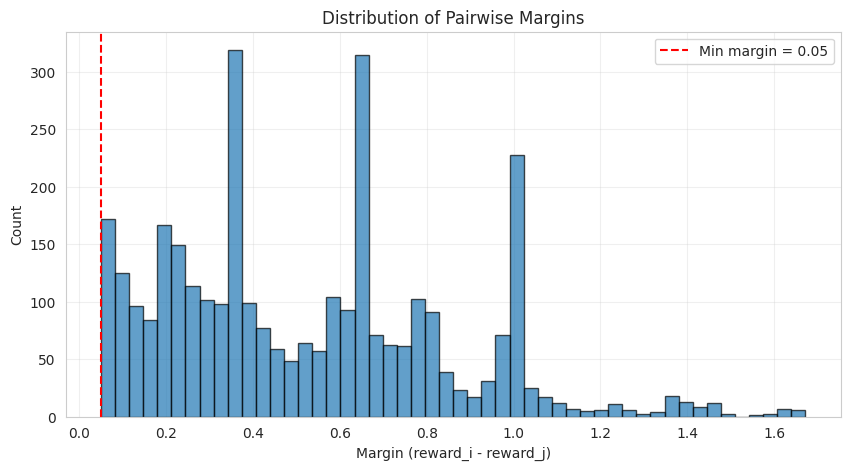

Median margin: 0.464
Mean margin: 0.522


In [14]:
# Visualize pair margin distribution
plt.figure(figsize=(10, 5))
plt.hist(df_pairs_train['margin'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Margin (reward_i - reward_j)')
plt.ylabel('Count')
plt.title('Distribution of Pairwise Margins')
plt.axvline(MIN_MARGIN, color='red', linestyle='--', label=f'Min margin = {MIN_MARGIN}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Median margin: {df_pairs_train['margin'].median():.3f}")
print(f"Mean margin: {df_pairs_train['margin'].mean():.3f}")

## 4. Build Pairwise Dataset

In [15]:
# Create model and mode mappings
unique_models = sorted(df_expanded['model_name'].unique())
unique_modes = sorted(df_expanded['mode_id'].unique())

model_to_id = {model: i for i, model in enumerate(unique_models)}
id_to_model = {i: model for model, i in model_to_id.items()}

mode_to_id = {mode: i for i, mode in enumerate(unique_modes)}
id_to_mode = {i: mode for mode, i in mode_to_id.items()}

print(f"Models ({len(model_to_id)}): {model_to_id}")
print(f"Modes ({len(mode_to_id)}): {mode_to_id}")

# Save mappings
with open(DATA_DIR / "model_index_pairwise.json", "w") as f:
    json.dump(model_to_id, f, indent=2)
with open(DATA_DIR / "mode_index_pairwise.json", "w") as f:
    json.dump(mode_to_id, f, indent=2)

print("\n✓ Saved model and mode index mappings")

Models (5): {'deepseek_ocr': 0, 'gemma_3_27b': 1, 'qwen2_5_vl_3b': 2, 'qwen2_5_vl_7b': 3, 'qwen3_vl_8b_thinking': 4}
Modes (4): {'accuracy': 0, 'balanced': 1, 'cheap': 2, 'fast': 3}

✓ Saved model and mode index mappings


In [16]:
# Create PyTorch dataset
train_dataset = PairwiseRouterDataset(
    pairs_df=df_pairs_train,
    model_to_id=model_to_id,
    mode_to_id=mode_to_id,
)

print(f"✓ Created training dataset: {len(train_dataset)} examples")

# Create dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_pairwise_batch,
)

print(f"✓ Created training dataloader: {len(train_loader)} batches")

# Test batch
sample_batch = next(iter(train_loader))
print("\nSample batch keys:", sample_batch.keys())
print("  sample_texts:", len(sample_batch['sample_texts']))
print("  model_i_ids:", sample_batch['model_i_ids'].shape)
print("  model_j_ids:", sample_batch['model_j_ids'].shape)
print("  mode_ids:", sample_batch['mode_ids'].shape)
print("  labels:", sample_batch['labels'].shape)

✓ Created training dataset: 3301 examples
✓ Created training dataloader: 207 batches

Sample batch keys: dict_keys(['sample_texts', 'model_i_ids', 'model_j_ids', 'mode_ids', 'labels'])
  sample_texts: 16
  model_i_ids: torch.Size([16])
  model_j_ids: torch.Size([16])
  mode_ids: torch.Size([16])
  labels: torch.Size([16])


## 5. Train Pairwise Router

In [17]:
# Initialize model
model = PairwiseRouterModel(
    num_models=len(model_to_id),
    num_modes=len(mode_to_id),
    text_encoder_name="distilbert-base-uncased",
    model_embed_dim=32,
    mode_embed_dim=16,
    hidden_dim=256,
    dropout=0.1,
)

model = model.to(DEVICE)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print(f"\n✓ Initialized model on {DEVICE}")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

2025-12-06 17:20:19,678 - models.pairwise_router - INFO - Initialized PairwiseRouterModel:
2025-12-06 17:20:19,679 - models.pairwise_router - INFO -   Models: 5, Modes: 4
2025-12-06 17:20:19,679 - models.pairwise_router - INFO -   Text encoder: distilbert-base-uncased (dim=768)
2025-12-06 17:20:19,680 - models.pairwise_router - INFO -   Model embed: 32, Mode embed: 16
2025-12-06 17:20:19,680 - models.pairwise_router - INFO -   Hidden dim: 256, Dropout: 0.1



✓ Initialized model on cuda
  Total parameters: 66,605,281
  Trainable parameters: 66,605,281


In [18]:
# Training loop
print(f"\nTraining for {NUM_EPOCHS} epochs...\n")

history = {
    'train_loss': [],
    'pairwise_accuracy': [],  # % of pairs where score_i > score_j
}

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_correct = 0
    epoch_total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    for batch in pbar:
        optimizer.zero_grad()
        
        # Forward pass
        loss = model.compute_pairwise_loss(
            sample_texts=batch['sample_texts'],
            model_i_ids=batch['model_i_ids'],
            model_j_ids=batch['model_j_ids'],
            mode_ids=batch['mode_ids'],
            margin=MARGIN,
        )
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        epoch_loss += loss.item()
        
        # Compute pairwise accuracy (score_i > score_j)
        with torch.no_grad():
            scores_i = model(
                batch['sample_texts'],
                batch['model_i_ids'],
                batch['mode_ids'],
            )
            scores_j = model(
                batch['sample_texts'],
                batch['model_j_ids'],
                batch['mode_ids'],
            )
            correct = (scores_i > scores_j).sum().item()
            epoch_correct += correct
            epoch_total += len(scores_i)
        
        pbar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc': f"{100 * correct / len(scores_i):.1f}%"
        })
    
    # Epoch statistics
    avg_loss = epoch_loss / len(train_loader)
    pairwise_acc = 100 * epoch_correct / epoch_total
    
    history['train_loss'].append(avg_loss)
    history['pairwise_accuracy'].append(pairwise_acc)
    
    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Pairwise Acc = {pairwise_acc:.2f}%")

print("\n✓ Training complete")


Training for 5 epochs...



Epoch 1/5:   0%|          | 0/207 [00:00<?, ?it/s]

Epoch 1: Loss = 0.9450, Pairwise Acc = 62.25%


Epoch 2/5:   0%|          | 0/207 [00:00<?, ?it/s]

Epoch 2: Loss = 0.8405, Pairwise Acc = 64.13%


...

Epoch 3: Loss = 0.7541, Pairwise Acc = 66.86%


Epoch 4/5:   0%|          | 0/207 [00:00<?, ?it/s]

Epoch 4: Loss = 0.6599, Pairwise Acc = 73.95%


Epoch 5/5:   0%|          | 0/207 [00:00<?, ?it/s]

Epoch 5: Loss = 0.5481, Pairwise Acc = 78.28%

✓ Training complete


In [26]:
# Save trained model
model_path = MODELS_DIR / "best_pairwise_router.pt"
torch.save({
    'model_state_dict': model.state_dict(),
    'model_to_id': model_to_id,
    'mode_to_id': mode_to_id,
    'config': {
        'num_models': len(model_to_id),
        'num_modes': len(mode_to_id),
        'text_encoder_name': 'distilbert-base-uncased',
        'model_embed_dim': 32,
        'mode_embed_dim': 16,
        'hidden_dim': 256,
        'dropout': 0.1,
    },
}, model_path)

print(f"✓ Saved model to {model_path}")

✓ Saved model to ../models/checkpoints/best_pairwise_router.pt


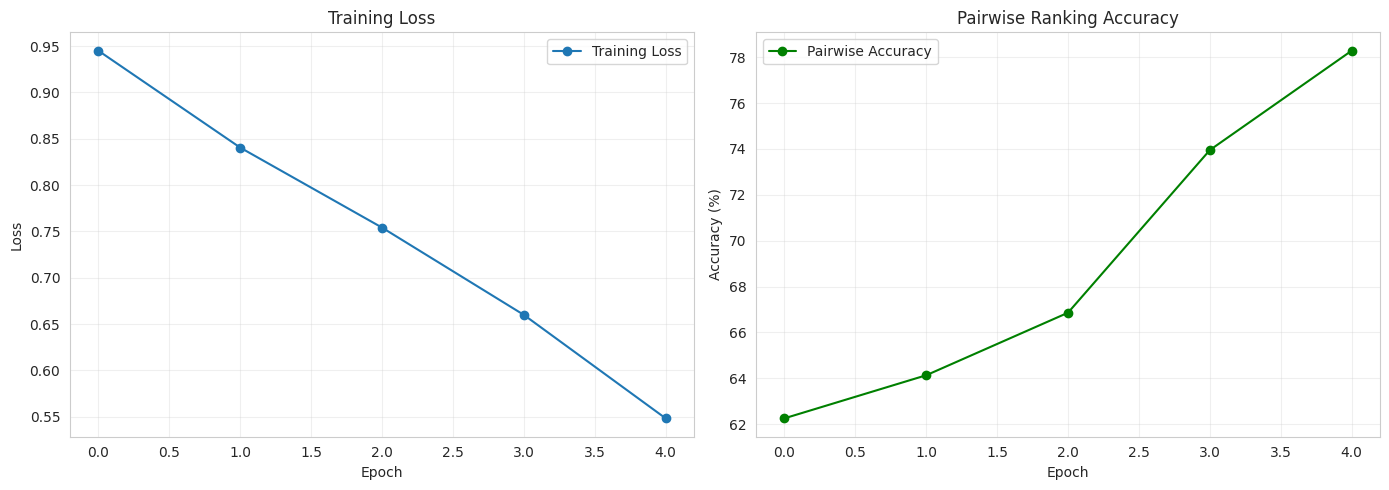

In [27]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], marker='o', label='Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Pairwise accuracy
axes[1].plot(history['pairwise_accuracy'], marker='o', color='green', label='Pairwise Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Pairwise Ranking Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Evaluate & Compare to Oracle

In [28]:
# Load validation data
print("Loading validation data...")

df_val_profiles = None
if USE_SQLITE_CACHE and SQLITE_DB_PATH.exists():
    print(f"  Source: SQLite -> {SQLITE_DB_PATH} ({SQLITE_TABLE_NAME})")
    df_val_profiles = load_from_sqlite(
        db_path=SQLITE_DB_PATH,
        table_name=SQLITE_TABLE_NAME,
        data_split="val",
        limit=500,
    )
else:
    if USE_SQLITE_CACHE:
        print(f"  SQLite file not found at {SQLITE_DB_PATH}, falling back to DB")
    df_val_profiles = load_profiles_real_schema(
        db_config=db_config,
        limit=500,  # Smaller validation set
        data_split="val",
    )

# Compute rewards
df_val_with_rewards = compute_rewards_real_schema(df_val_profiles, reward_weights)

# Expand modes
val_expanded_rows = []
for _, row in df_val_with_rewards.iterrows():
    for mode in modes:
        mode_id = mode_to_id[mode]
        val_expanded_rows.append({
            **row,
            "mode_name": mode,
            "mode_id": mode_id,
            "reward": row[f"reward_{mode}"],
        })

df_val_expanded = pd.DataFrame(val_expanded_rows)


2025-12-06 17:24:42,972 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-06 17:24:42,972 - db_utils - INFO - Loading from ../data/vlm_router_cache.db:vlm_profiles
2025-12-06 17:24:42,972 - db_utils - INFO -   Filtering by data_split: val
2025-12-06 17:24:42,973 - db_utils - INFO -   Limit: 500
2025-12-06 17:24:42,979 - db_utils - INFO - Loaded 500 rows
2025-12-06 17:24:42,980 - db_utils - INFO -   Unique samples: 129
2025-12-06 17:24:42,980 - db_utils - INFO -   Unique models: 5
2025-12-06 17:24:42,981 - db_utils - INFO -   Data splits: {'val': 500}
2025-12-06 17:24:42,981 - reward_definitions - INFO - Computing rewards for all modes (using real schema with glider_score)...
2025-12-06 17:24:42,983 - reward_definitions - INFO - Using glider_score as primary accuracy (mean=0.658)
2025-12-06 17:24:42,985 - reward_definitions - INFO - Cost normalized: quantile=0.001287, mean=0.257
2025-12-06 17:24:42,986 - reward_definitions - INFO - Latency normalized: qua

Loading validation data...
  Source: SQLite -> ../data/vlm_router_cache.db (vlm_profiles)


In [30]:
# Evaluate routing accuracy vs oracle
print("Evaluating routing accuracy...")

model.eval()
results = []

# Resolve mode id whether stored as string or int
def _resolve_mode_idx(mode_value):
    if mode_value in mode_to_id:
        return mode_to_id[mode_value]
    try:
        mid_int = int(mode_value)
        if mid_int in id_to_mode:
            return mid_int
    except Exception:
        pass
    raise KeyError(f"Unknown mode_id: {mode_value}")

# Group by (sample_id, mode_id)
grouped = df_val_expanded.groupby(["sample_id", "mode_id"])

for (sample_id, mode_id), group in tqdm(grouped, desc="Evaluating"):
    mode_idx = _resolve_mode_idx(mode_id)
    mode_name = id_to_mode.get(mode_idx, str(mode_id))
    
    # Oracle choice (best reward)
    oracle_choice = group.loc[group["reward"].idxmax(), "model_name"]
    oracle_reward = group["reward"].max()
    
    # Router prediction
    sample_text = group.iloc[0]["prompt_raw"]  # Same for all models
    available_models = group["model_name"].tolist()
    available_model_ids = [model_to_id[m] for m in available_models]
    
    with torch.no_grad():
        predicted_ids = model.predict_best_model(
            sample_texts=[sample_text],
            model_ids=available_model_ids,
            mode_id=mode_idx,
        )
        predicted_model_id = predicted_ids[0]
        predicted_model = id_to_model[predicted_model_id]
    
    # Get router's reward
    router_reward = group.loc[group["model_name"] == predicted_model, "reward"].values[0]
    
    results.append({
        "sample_id": sample_id,
        "mode_id": mode_idx,
        "mode_name": mode_name,
        "oracle_choice": oracle_choice,
        "oracle_reward": oracle_reward,
        "router_choice": predicted_model,
        "router_reward": router_reward,
        "correct": oracle_choice == predicted_model,
        "reward_gap": oracle_reward - router_reward,
    })

df_results = pd.DataFrame(results)

# Print results
overall_acc = 100 * df_results["correct"].mean()
avg_gap = df_results["reward_gap"].mean()
median_gap = df_results["reward_gap"].median()

print("" + "="*60)
print("EVALUATION RESULTS")
print("="*60)
print(f"Routing Accuracy: {overall_acc:.2f}%")
print(f"Average Reward Gap: {avg_gap:.4f}")
print(f"Median Reward Gap: {median_gap:.4f}")
print(f"Oracle Reward (avg): {df_results['oracle_reward'].mean():.4f}")
print(f"Router Reward (avg): {df_results['router_reward'].mean():.4f}")
print("="*60)

# Per-mode breakdown
print("Per-mode breakdown:")
for mode_idx, mode_name in sorted(id_to_mode.items()):
    mode_results = df_results[df_results["mode_id"] == mode_idx]
    mode_acc = 100 * mode_results["correct"].mean()
    mode_gap = mode_results["reward_gap"].mean()
    print(f"  {mode_name:12s}: Acc = {mode_acc:5.2f}%, Gap = {mode_gap:.4f}")


Evaluating routing accuracy...


Evaluating:   0%|          | 0/516 [00:00<?, ?it/s]

EVALUATION RESULTS
Routing Accuracy: 27.91%
Average Reward Gap: 0.1747
Median Reward Gap: 0.0164
Oracle Reward (avg): 0.8052
Router Reward (avg): 0.6305
Per-mode breakdown:
  accuracy    : Acc = 31.01%, Gap = 0.1439
  balanced    : Acc = 28.68%, Gap = 0.1725
  cheap       : Acc = 26.36%, Gap = 0.1892
  fast        : Acc = 25.58%, Gap = 0.1931


## 7. Visualizations

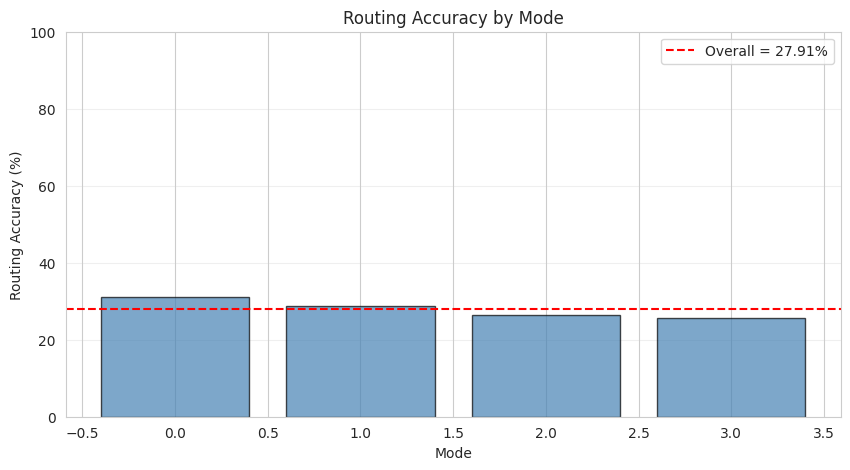

In [31]:
# Routing accuracy by mode
mode_acc = df_results.groupby('mode_id')['correct'].mean() * 100

plt.figure(figsize=(10, 5))
plt.bar(mode_acc.index, mode_acc.values, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Mode')
plt.ylabel('Routing Accuracy (%)')
plt.title('Routing Accuracy by Mode')
plt.axhline(overall_acc, color='red', linestyle='--', label=f'Overall = {overall_acc:.2f}%')
plt.ylim([0, 100])
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.show()

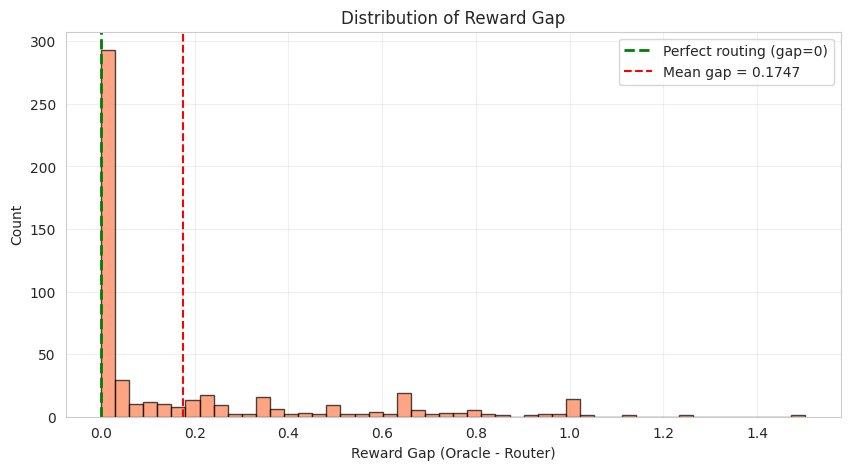


Perfect routing rate: 39.34%


In [32]:
# Reward gap distribution
plt.figure(figsize=(10, 5))
plt.hist(df_results['reward_gap'], bins=50, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Reward Gap (Oracle - Router)')
plt.ylabel('Count')
plt.title('Distribution of Reward Gap')
plt.axvline(0, color='green', linestyle='--', linewidth=2, label='Perfect routing (gap=0)')
plt.axvline(avg_gap, color='red', linestyle='--', label=f'Mean gap = {avg_gap:.4f}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

perfect_routing = (df_results['reward_gap'] == 0).mean() * 100
print(f"\nPerfect routing rate: {perfect_routing:.2f}%")

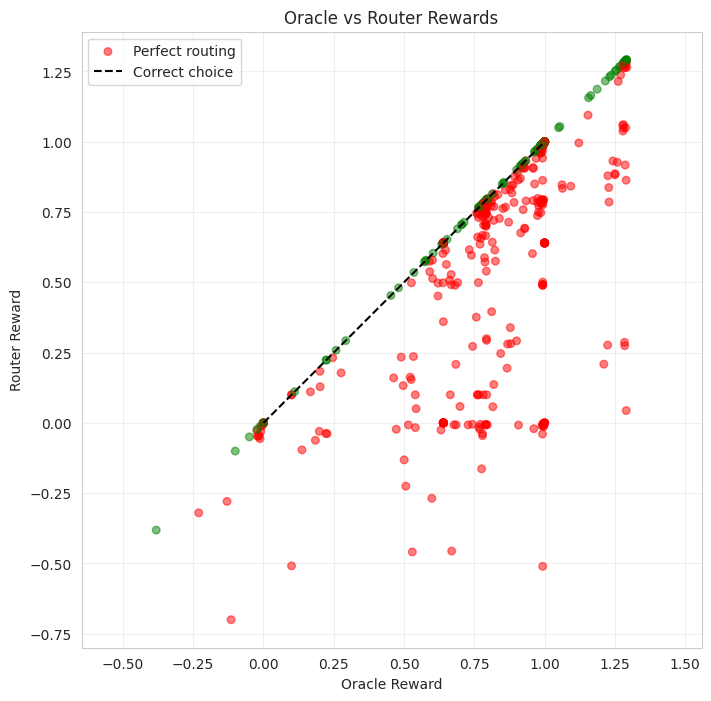

In [33]:
# Oracle vs Router rewards scatter
plt.figure(figsize=(8, 8))
plt.scatter(
    df_results['oracle_reward'],
    df_results['router_reward'],
    alpha=0.5,
    s=30,
    c=df_results['correct'].map({True: 'green', False: 'red'}),
)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect routing')
plt.xlabel('Oracle Reward')
plt.ylabel('Router Reward')
plt.title('Oracle vs Router Rewards')
plt.grid(True, alpha=0.3)
plt.legend(['Perfect routing', 'Correct choice', 'Incorrect choice'])
plt.axis('equal')
plt.show()

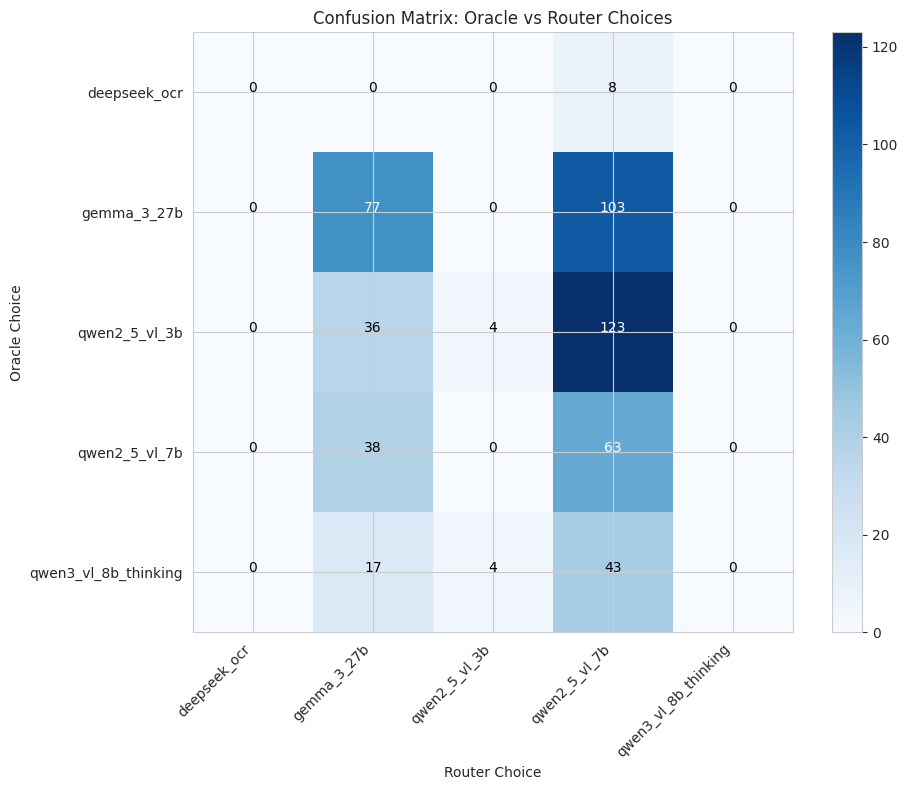

In [34]:
# Confusion matrix of model choices
from sklearn.metrics import confusion_matrix
import itertools

# Get oracle and router choices as model IDs
oracle_ids = [model_to_id[m] for m in df_results['oracle_choice']]
router_ids = [model_to_id[m] for m in df_results['router_choice']]

cm = confusion_matrix(oracle_ids, router_ids)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix: Oracle vs Router Choices')
plt.colorbar()
tick_marks = np.arange(len(model_to_id))
plt.xticks(tick_marks, [id_to_model[i] for i in range(len(model_to_id))], rotation=45, ha='right')
plt.yticks(tick_marks, [id_to_model[i] for i in range(len(model_to_id))])

# Add text annotations
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('Oracle Choice')
plt.xlabel('Router Choice')
plt.tight_layout()
plt.show()

[PERFORMANCE DIAGNOSTICS]


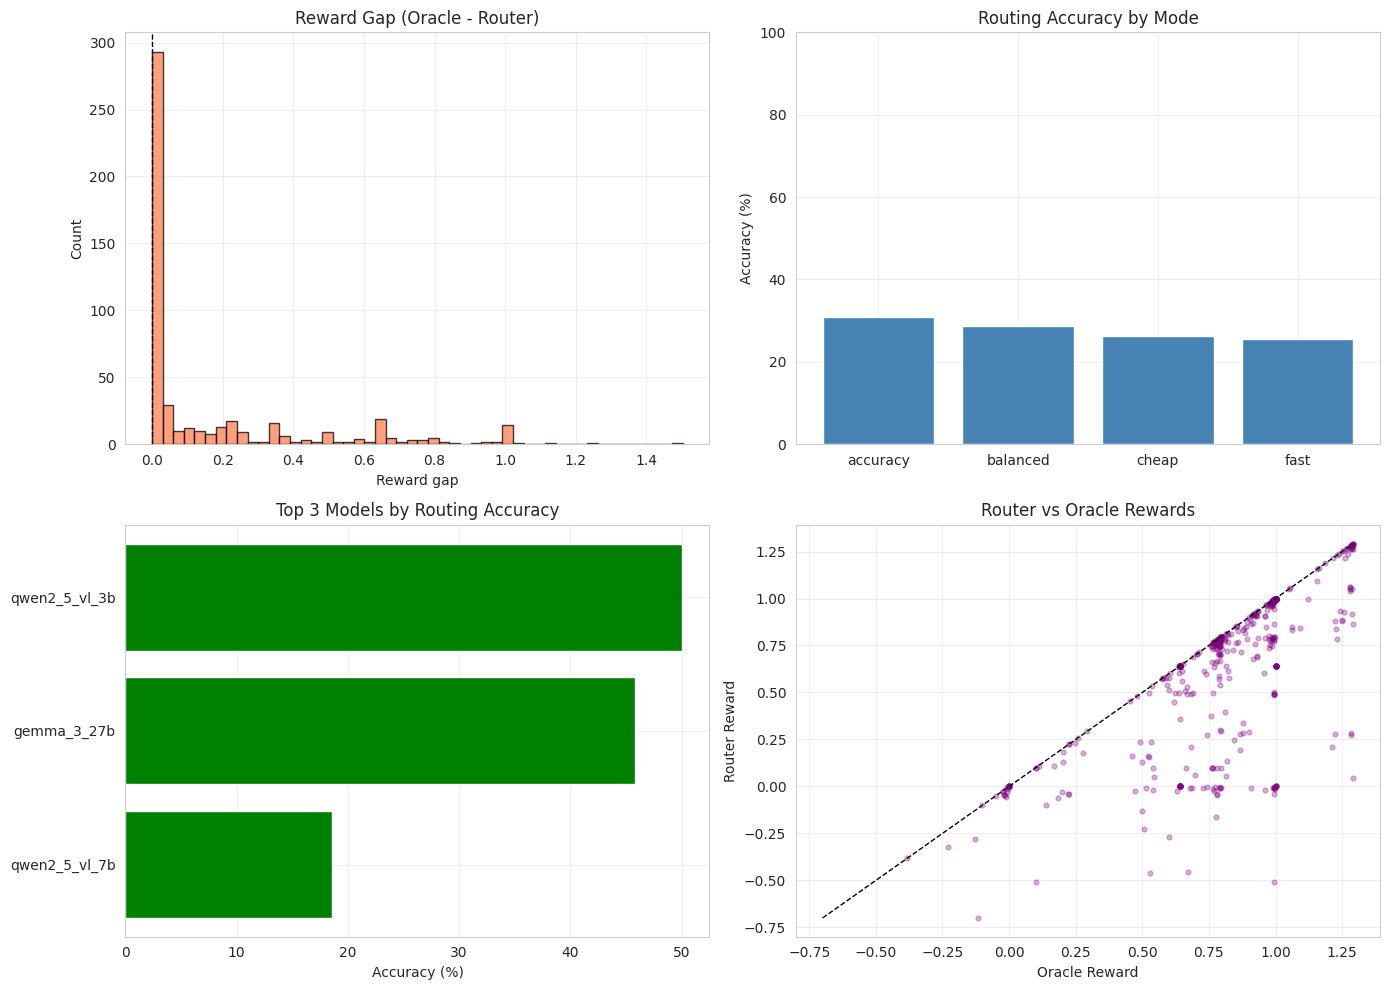

[SUMMARY METRICS]
Overall accuracy: 27.91%
Mean reward gap: 0.1747 | Median: 0.0164
  accuracy     Acc = 31.01% | Gap = 0.1439
  balanced     Acc = 28.68% | Gap = 0.1725
  cheap        Acc = 26.36% | Gap = 0.1892
  fast         Acc = 25.58% | Gap = 0.1931


In [35]:
# Extra diagnostics: reward gaps, accuracy, and per-model stats
print('[PERFORMANCE DIAGNOSTICS]')

reward_gap = df_results['reward_gap']
mode_acc = df_results.groupby('mode_id')['correct'].mean().sort_index()
gap_by_mode = df_results.groupby('mode_id')['reward_gap'].mean().sort_index()
per_model_acc = df_results.groupby('router_choice')['correct'].mean().sort_values(ascending=False)

mode_labels = [id_to_mode[m] if 'id_to_mode' in globals() else str(m) for m in mode_acc.index]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Reward gap histogram
axes[0, 0].hist(reward_gap, bins=50, color='coral', edgecolor='black', alpha=0.75)
axes[0, 0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Reward Gap (Oracle - Router)')
axes[0, 0].set_xlabel('Reward gap')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(alpha=0.3)

# Accuracy by mode
axes[0, 1].bar(mode_labels, mode_acc.values * 100, color='steelblue')
axes[0, 1].set_ylim(0, 100)
axes[0, 1].set_title('Routing Accuracy by Mode')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].grid(alpha=0.3)

# Top models by accuracy
top_n = min(10, len(per_model_acc))
axes[1, 0].barh(per_model_acc.head(top_n).index[::-1], per_model_acc.head(top_n).values[::-1] * 100, color='green')
axes[1, 0].set_title(f'Top {top_n} Models by Routing Accuracy')
axes[1, 0].set_xlabel('Accuracy (%)')
axes[1, 0].grid(alpha=0.3)

# Oracle vs Router rewards scatter
min_r = min(df_results['oracle_reward'].min(), df_results['router_reward'].min())
max_r = max(df_results['oracle_reward'].max(), df_results['router_reward'].max())
axes[1, 1].scatter(df_results['oracle_reward'], df_results['router_reward'], alpha=0.3, s=12, color='purple')
axes[1, 1].plot([min_r, max_r], [min_r, max_r], 'k--', linewidth=1)
axes[1, 1].set_xlabel('Oracle Reward')
axes[1, 1].set_ylabel('Router Reward')
axes[1, 1].set_title('Router vs Oracle Rewards')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('[SUMMARY METRICS]')
print(f"Overall accuracy: {mode_acc.mean() * 100:.2f}%")
print(f"Mean reward gap: {reward_gap.mean():.4f} | Median: {reward_gap.median():.4f}")
mode_info = list(zip(mode_labels, mode_acc.values, gap_by_mode.values))
for label, acc, gap in mode_info:
    print(f"  {label:12s} Acc = {acc*100:5.2f}% | Gap = {gap:.4f}")


## Summary

This notebook demonstrated training a **pairwise ranking router** for VLM routing:

### Key Results
- **Pairwise Training Accuracy**: Measures how well the model ranks model pairs
- **Routing Accuracy**: How often the router picks the same model as the oracle
- **Reward Gap**: Difference between oracle and router rewards

### Next Steps
1. **Tune hyperparameters**: Adjust margin, learning rate, min_margin
2. **Compare approaches**: Run `04_classical_ce_kl_router.ipynb` to compare
3. **Test set evaluation**: Evaluate on held-out test set
4. **Production deployment**: Use trained model for real-time routing

### Files Generated
- `../models/checkpoints/best_pairwise_router.pt` - Trained model
- `../data/model_index_pairwise.json` - Model ID mappings
- `../data/mode_index_pairwise.json` - Mode ID mappings